In [255]:
# 1. Management and Reserach Questions
# Basic Information about dataset: It is a dataset in which we try to predict the Housing prices based on several factors
# such as:
# Land: Lot Area, Lot Frontage, Lot Shape, Street
# Location: Neighborhood, Zoning, Condition
# House Quality: Overall Qual, Overall Cond
# Age: Year Built, Year Remod/Add
# Size: Gr Liv Area, Total Bsmt SF, Garage Area
# Rooms: Bedrooms, Bathrooms, Kitchens
# Amenities: Fireplace, Garage, Pool, Porch, Deck
# Sale Details: Sale Type, Sale Condition, SalePrice

# This is a supervised Learning problem in which we are supposed to predict the SalesPrice of the data, all of these seem to
# provide very good information in which salesprice of the land can heavily depend on

In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import ( OrdinalEncoder, OneHotEncoder, StandardScaler)
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [257]:
df = pd.read_csv("AmesHousing.csv")

In [258]:
df.head()
print(df.shape)
print(df.describe())
# SalePrice is positively (right) skewed, as the mean is noticeably larger than the median.
# Most numerical features have reasonable minimum and maximum values, suggesting no obvious data-entry errors.
# Porch-related features (e.g., Open Porch SF, Enclosed Porch, Screen Porch) have medians close to 0
# and means much larger than the medians, indicating highly right-skewed distributions.
# This likely reflects that many houses have no porch, while a smaller number have large porches.
# These observations should be verified using histograms and boxplots before deciding on any transformations.

(2930, 82)
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026      1.111537    30.245361       20

In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

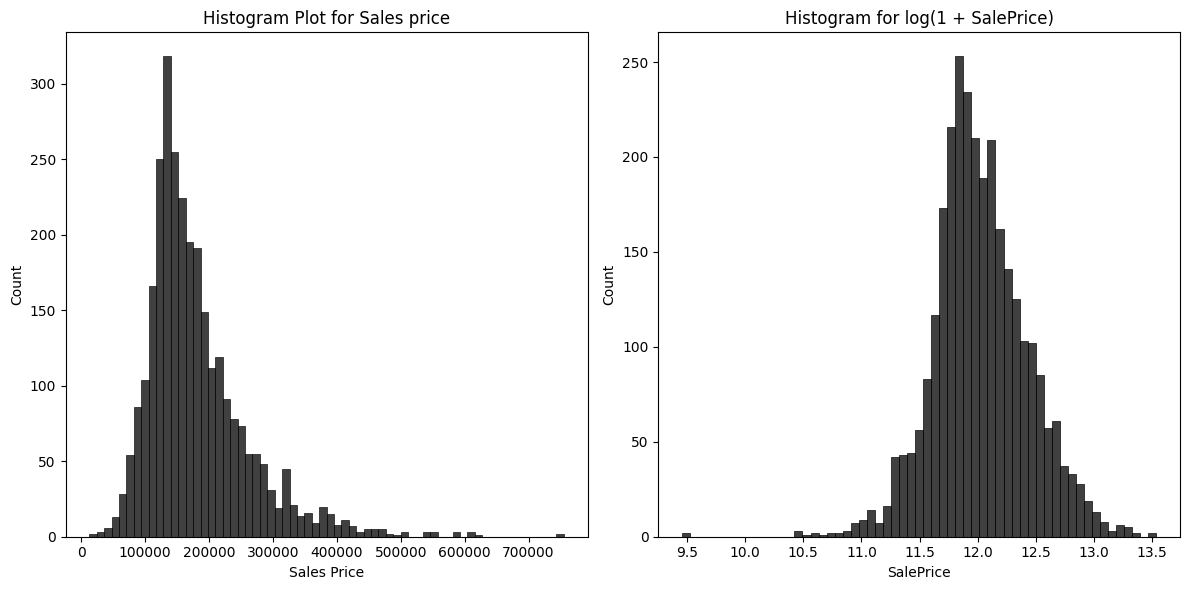

Skewness of SalePrice 1.744
Skewess for log(1 + SalePrice) -0.015


In [260]:
#Lets check the skewness of the target variable which needs deepest invesigation
fig, axes = plt.subplots(1, 2, figsize = (12,6))
sns.histplot(df["SalePrice"], ax = axes[0], color = "Black")
axes[0].set_title("Histogram Plot for Sales price")
axes[0].set_xlabel("Sales Price")
# # from which we can see that the target is right skewed cause there is a long tail which means that the most land being
# sold are at prices between 10k to 20k. So, to counter this we can use put log(1 + SalePrice) for good distribution
sns.histplot(np.log1p(df["SalePrice"]), ax = axes[1], color = "Black")
axes[1].set_title("Histogram for log(1 + SalePrice)")
axes[1].set_xlabel("SalePrice")
plt.tight_layout()
plt.show()

print("Skewness of SalePrice", np.round(df["SalePrice"].skew(), 3))
print("Skewess for log(1 + SalePrice)", np.round(np.log1p(df["SalePrice"]).skew(),3))
# the value is in range of -0.5 to 0.5 so it is now approxitmately symeetric


In [261]:
df["SalePrice_log"] = np.log1p(df["SalePrice"])
print(df["SalePrice_log"]) #storing the log value and have to remember that at the time or prediction do _log#

0       12.278398
1       11.561725
2       12.055256
3       12.404928
4       12.154258
          ...    
2925    11.867104
2926    11.782960
2927    11.790565
2928    12.043560
2929    12.144203
Name: SalePrice_log, Length: 2930, dtype: float64


Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
SalePrice_log       0
Length: 83, dtype: int64


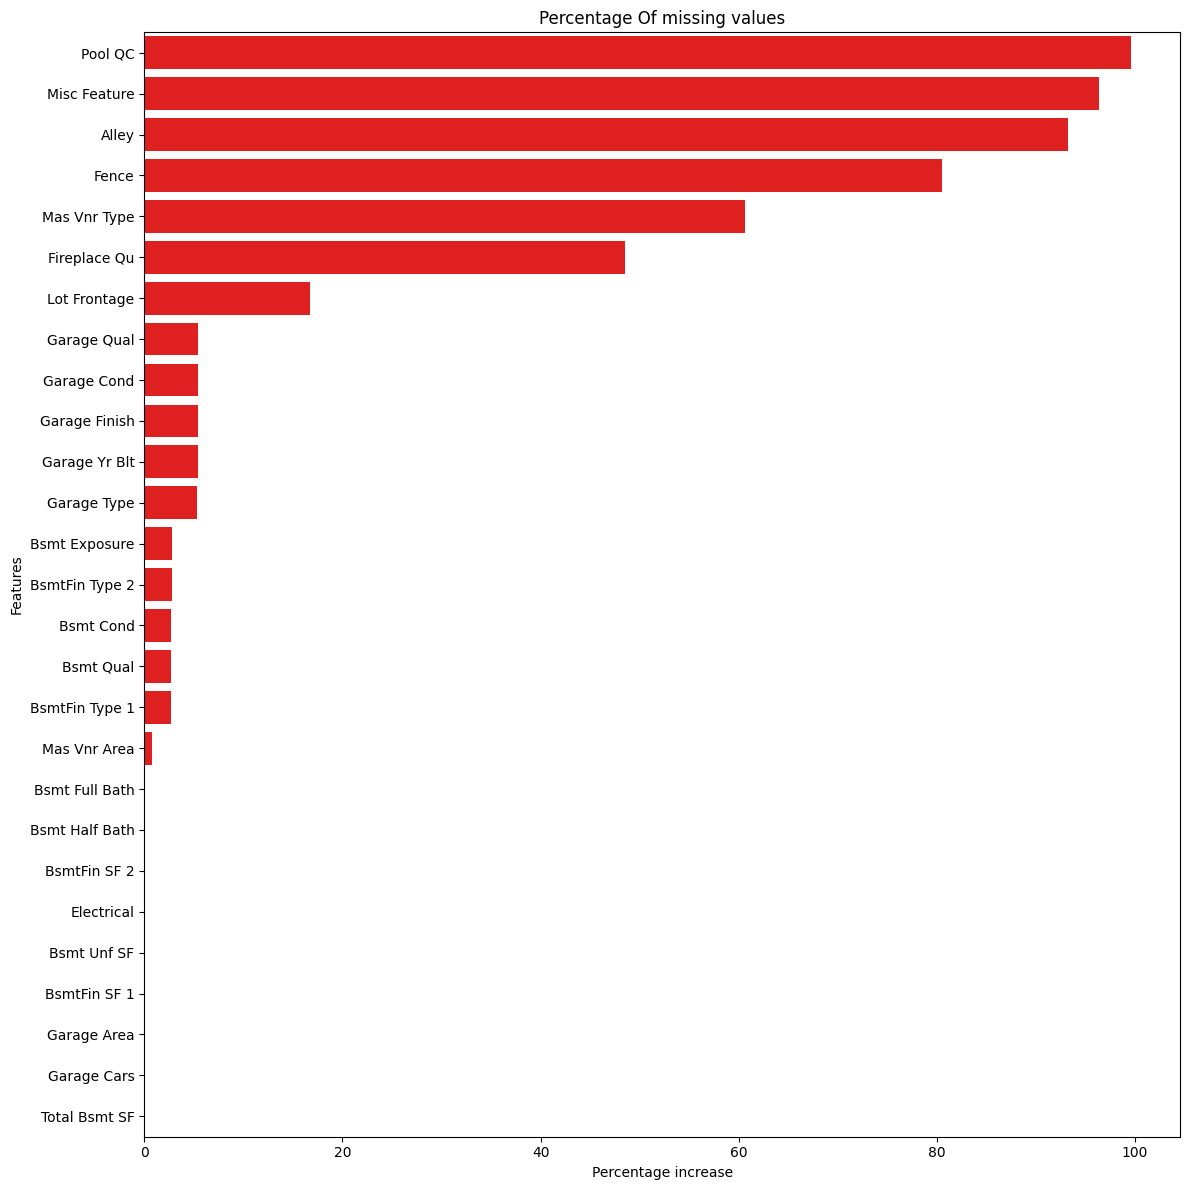

In [262]:
#let's check Missing data now
missing = df.isnull().sum()
print(missing)
missing_percent = (missing/len(df)*100).sort_values(ascending = False)
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize = (12,12))
sns.barplot(x = missing_percent.values, y = missing_percent.index, color = "Red")
plt.title("Percentage Of missing values")
plt.xlabel("Percentage increase")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#as per this we can see that following have most missing values
# PoolQC = shows if the lot as pool or not, a important feature cause pool prices can increase prices a lot and can't fill
# with any other values so filling it with Na is appropriate
# Misc Feature = Can be important the same way have to see coorelation to confirm
# Alley = same
# Fence = a lot having fence can give sense of protection so it can help as well can't drop it
# Mas Vnr type = refers to the protective layer on the outside of home very important
# fireplace Qu = fireplace can increase prices can't drop this as well

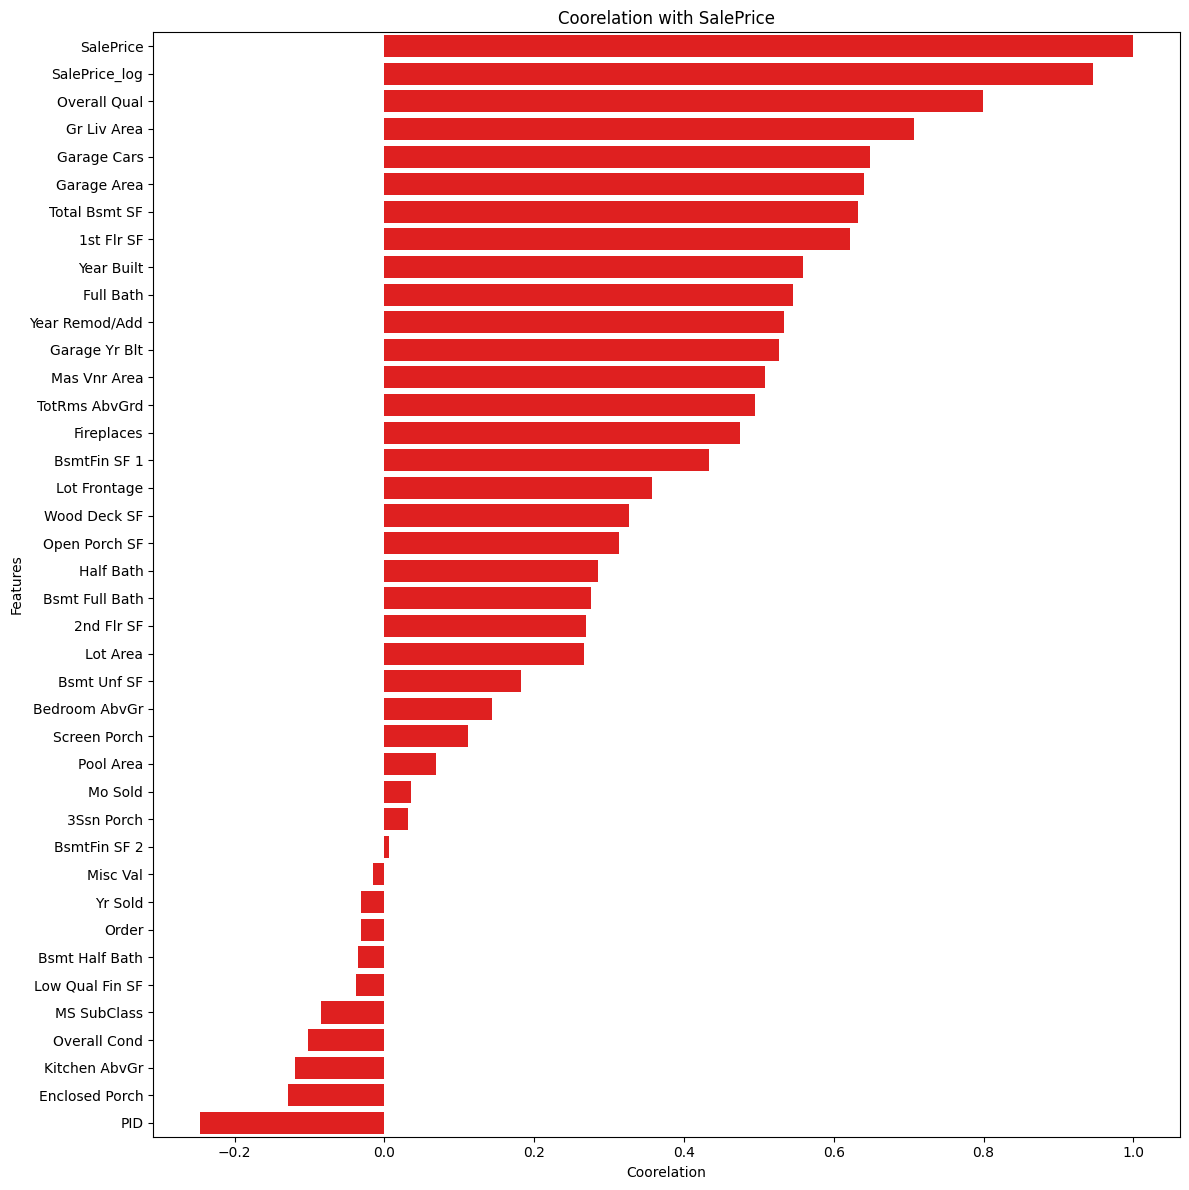

In [263]:
from numpy.random import SFC64
#let's see the coorelation of numeric features with the sales price so we will use scatterplot in this
numeric_cols = df.select_dtypes(include = [np.number]).columns
corr = df[numeric_cols].corr()["SalePrice"].sort_values(ascending = False)
plt.figure(figsize = (12,12))
sns.barplot(x = corr.values, y = corr.index, color = "Red")
plt.title("Coorelation with SalePrice")
plt.xlabel("Coorelation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
# overrall quality has high relation as higher quality price the sale price
# gv live area = grade living area is the total place after building is finisshed above ground level
# garage cars and garage area both high both should be highly correlated as well, maybe we can feature engineer to find something out of it
# total bsmt sf very important as it is the total basemant surface area same for 1floor SFC64
# year build of course

['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath', 'Year Remod/Add']


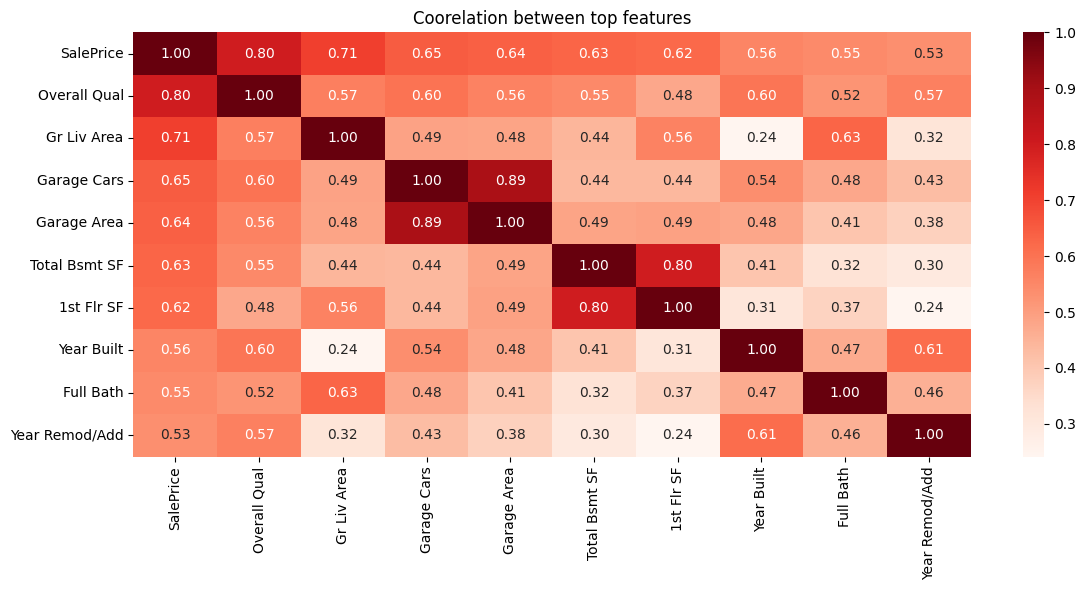

In [264]:
# to see the relationship between features like in the above we saw like the garage area and garage cars have about same coreelation let's check the coorelation among them to find other things from the top 10 values of corr
# top_corr = corr.head(10)
# print(top_corr) # so the two coloumns are showing so will be better to drop the salepricelog
top_corr = corr.drop(["SalePrice_log"]).head(10).index.tolist()
print(top_corr) # now let's show this in heatmap
plt.figure(figsize = (12,6))
sns.heatmap(df[top_corr].corr(), annot = True, fmt = ".2f", cmap = "Reds") # annote = True means it gives value inside box, fmt means the rounding of decimals, cmap = color
plt.title("Coorelation between top features")
plt.tight_layout()
plt.show()

# as thought previously garage area and garage cars have high coorelation
#total basement size and 1flr 1f is also related as the basement provides area for the 1 floor
#year remolded and year build also related cause newer houses may not require modeling
#overal quality has coorelation with many features same to a lesser degree for the garage cars cause it increases the area

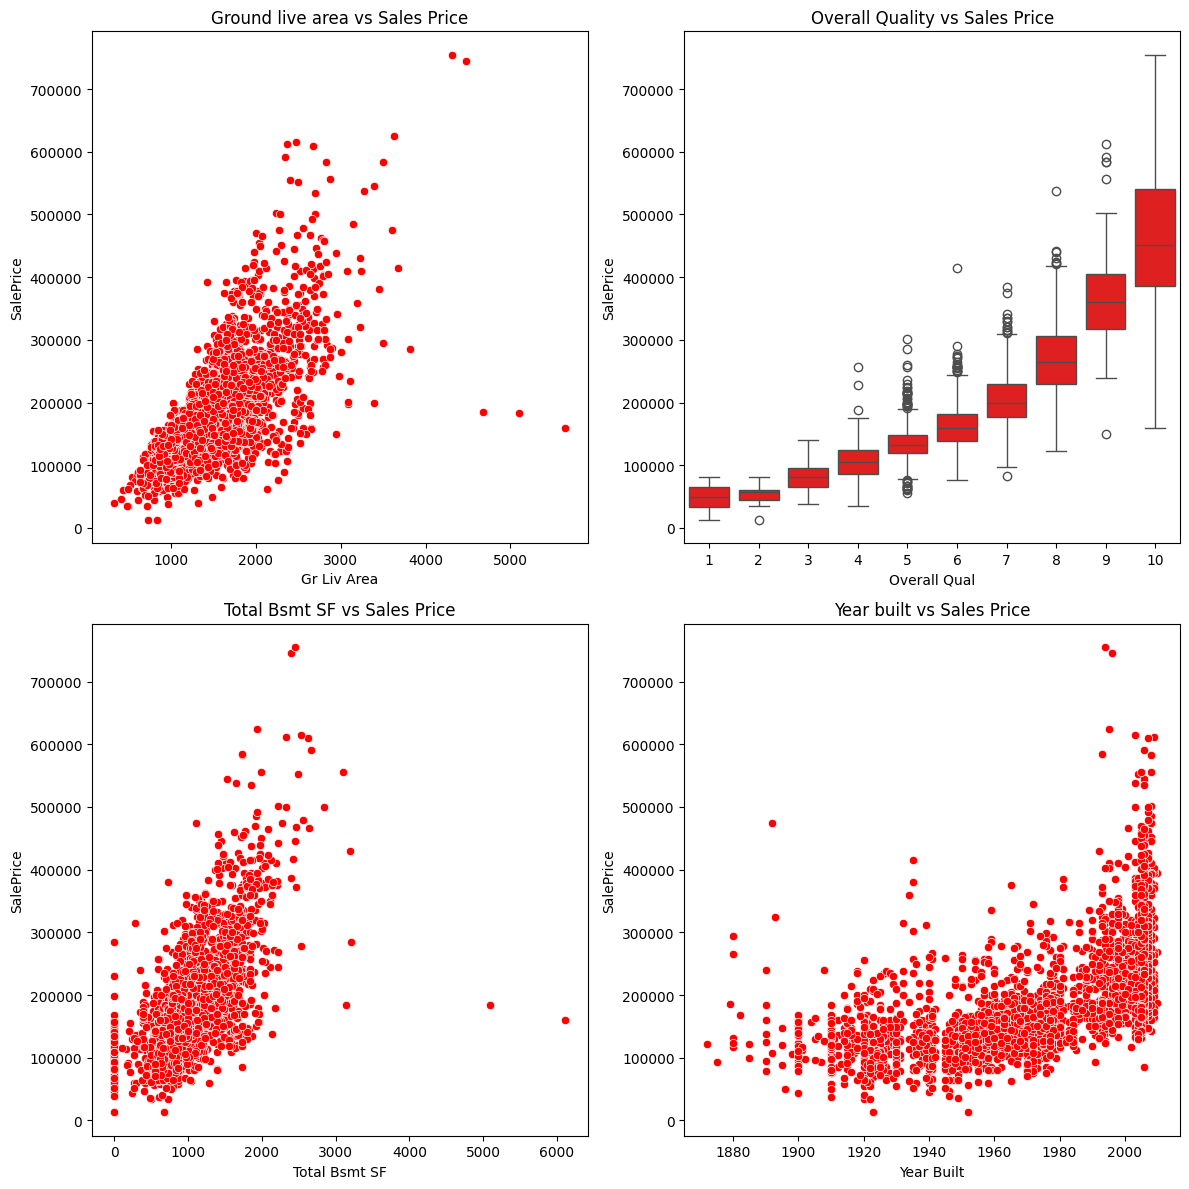

In [265]:
# # to fully furnish the relation let's see the scatterplot of the top 3 4 features with the target and check for outliers too
# #chossing these columns cause they tell soething new about the data like gv liv area tells story about area above ground and sales, overall qualy
# gives idea about quality, total bsmt gives the idea about the area on the ground, year build about the time and sales relationshiop
fig, axes = plt.subplots(2,2, figsize = (12,12))
sns.scatterplot(data = df, x = "Gr Liv Area", y = "SalePrice", ax = axes[0,0], color = "Red")
axes[0,0].set_title("Ground live area vs Sales Price")
sns.boxplot(data = df, x = "Overall Qual", y = "SalePrice", ax = axes[0,1], color = "Red") # cause it is a categorial data used boxplot
axes[0,1].set_title("Overall Quality vs Sales Price")
sns.scatterplot(data = df, x = "Total Bsmt SF", y = "SalePrice", ax = axes[1,0], color = "Red")
axes[1,0].set_title("Total Bsmt SF vs Sales Price")
sns.scatterplot(data = df, x = "Year Built", y = "SalePrice", ax = axes[1,1], color = "Red")
axes[1,1].set_title("Year built vs Sales Price")
plt.tight_layout()
plt.show()
#Gr Liv area has a ruoghly linear relationship with sales,
#overall quality is a bit complex one we can see the median increase as the quality increase but the amount of outliers also increases as the quality increases.
#total bsmt df relatiosnship shows like there are many which have no basement floor but other than that there is a linear relationshiop
#year build there are some outliers in the older section maybe cause it is heritages or something that are costly now besides those it is a very non linear type of data

In [266]:
# Summary of all the finding from eda and what can be done in feature engerring possible idea
# 1. since the garage area and garage cars are related higgly then maybe multiply them
# 2. have to fill in the missing data with good fillna as well
# 3. there are a lot of surface area so calculation it together can help

In [267]:
# 1. Clean features and remove impossible data
#removing the some outliers
outlier_idx = df[(df["Gr Liv Area"] > 4000) & (df["SalePrice"] < 300000)].index # we used .index to get the column name only
df.drop(outlier_idx, inplace =True)

#2. Filling the data as per the missing values
print(missing.sort_values(ascending = False).head(10))
# For pool QC
print(df["Pool QC"].unique()) #since it is a catagorial table and we can't drop it we are going to fill it some text
df["Pool QC"] = df["Pool QC"].fillna("No pool")
print(df["Misc Feature"].unique()) #same for this as well
df["Alley"] = df["Alley"].fillna("NaN")
df["Fence"] = df["Fence"].fillna("NaN")
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("NaN")
df["Fireplace Qu"] = df["Fireplace Qu"].fillna("NaN")

#Now let's look at numeric coloumns and fill them uppppp
print(df["Lot Frontage"].value_counts()) # it has normal distribution so will be good to fill with median
df["Lot Frontage"] = df["Lot Frontage"].fillna(0) #since we are using xgboost it can handle it
print(df["Garage Qual"].value_counts()) #it represents quality so we can't use mean or median
print(df["Garage Finish"].value_counts())

mew = df.isnull().sum().sort_values(ascending = False).head(15)
print(mew)
none_fill_cols = [
    "Garage Type",
    "Bsmt Exposure",
    "BsmtFin Type 2",
    "BsmtFin Type 1",
    "Bsmt Qual",
    "Bsmt Cond",
    "Garage Finish",
    "Garage Cond",
    "Garage Qual",
]
df[none_fill_cols] = df[none_fill_cols].fillna("None")

zero_fill_cols = [
    "Mas Vnr Area",
    "Bsmt Half Bath",
    "Bsmt Full Bath",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Garage Cars",
    "Garage Area",
    "BsmtFin SF 1"
]

df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

# Electrical system exists but the type is unknown
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])







Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Cond       159
Garage Finish     159
dtype: int64
[nan 'Ex' 'Gd' 'TA' 'Fa']
[nan 'Gar2' 'Shed' 'Othr' 'TenC']
Lot Frontage
60.0     276
80.0     137
70.0     133
50.0     117
75.0     105
        ... 
168.0      1
111.0      1
131.0      1
153.0      1
133.0      1
Name: count, Length: 128, dtype: int64
Garage Qual
TA    2612
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64
Garage Finish
Unf    1231
RFn     812
Fin     725
Name: count, dtype: int64
Misc Feature      2822
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
BsmtFin Type 1      80
Bsmt Cond           80
Bsmt Qual           80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
Bsmt Unf SF          

In [268]:
# 3.Checking if some objects needs conversion or not
cat_cols = df.select_dtypes(include = "object").columns
print(df[cat_cols].nunique().sort_values(ascending = False))
df["MS SubClass"] = df["MS SubClass"].astype(str)
df = df.drop(columns = ["PID", "Order"])
num_cols = df.select_dtypes(include="number").columns


Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Condition 2        8
MS Zoning          7
BsmtFin Type 2     7
BsmtFin Type 1     7
Garage Type        7
Roof Matl          7
Bsmt Qual          6
Sale Condition     6
Fireplace Qu       6
Bsmt Cond          6
Roof Style         6
Garage Cond        6
Garage Qual        6
Heating            6
Foundation         6
Fence              5
Bldg Type          5
Bsmt Exposure      5
Lot Config         5
Exter Cond         5
Kitchen Qual       5
Pool QC            5
Electrical         5
Heating QC         5
Mas Vnr Type       5
Lot Shape          4
Land Contour       4
Exter Qual         4
Misc Feature       4
Garage Finish      4
Alley              3
Utilities          3
Paved Drive        3
Land Slope         3
Street             2
Central Air        2
dtype: int64


In [269]:
#Feature Engerrning
df["Has Garage"] = (df["Garage Area"] > 0).astype(int)
df["Has Pool"] = (df["Pool Area"] > 0).astype(int)
df["Has Fireplace"] = (df["Fireplaces"] > 0).astype(int)
df["Total SF"] = (df["1st Flr SF"] + df["2nd Flr SF"] + df["Total Bsmt SF"])
df["House Age"] = df["Yr Sold"] - df["Year Built"]
df["Total Porch"] = (df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"] + df["Screen Porch"])


In [270]:
#Encoding
cat_cals = df.select_dtypes(include = "object").columns
num_cals = df.select_dtypes(include = "number").columns

In [271]:
for col in cat_cols:
    print("=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False))

MS Zoning
MS Zoning
RL         2270
RM          462
FV          139
RH           27
C (all)      25
I (all)       2
A (agr)       2
Name: count, dtype: int64
Street
Street
Pave    2915
Grvl      12
Name: count, dtype: int64
Alley
Alley
NaN     2729
Grvl     120
Pave      78
Name: count, dtype: int64
Lot Shape
Lot Shape
Reg    1859
IR1     977
IR2      76
IR3      15
Name: count, dtype: int64
Land Contour
Land Contour
Lvl    2633
HLS     120
Bnk     114
Low      60
Name: count, dtype: int64
Utilities
Utilities
AllPub    2924
NoSewr       2
NoSeWa       1
Name: count, dtype: int64
Lot Config
Lot Config
Inside     2138
Corner      510
CulDSac     180
FR2          85
FR3          14
Name: count, dtype: int64
Land Slope
Land Slope
Gtl    2786
Mod     125
Sev      16
Name: count, dtype: int64
Neighborhood
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    191
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    

In [272]:
ordinal_cols = [
    "Exter Qual",
    "Exter Cond",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Heating QC",
    "Kitchen Qual",
    "Functional",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Pool QC",
    "Fence",
    "Land Slope",
    "Lot Shape"
]

binary_cols = [
    "Central Air"
]

ohe_cols = [
    "MS Zoning",
    "Land Contour",
    "Lot Config",
    "Neighborhood",
    "Condition 1",
    "Condition 2",
    "Bldg Type",
    "Roof Style",
    "Exterior 1st",
    "Exterior 2nd",
    "Mas Vnr Type",
    "Foundation",
    "Heating",
    "Electrical",
    "Garage Type",
    "Sale Type",
    "Sale Condition"
]

In [273]:
drop_cols = [
    "Utilities",
    "Street",
    "Alley",
    "Roof Matl",
    "Misc Feature",
]
df = df.drop(columns = drop_cols, errors = 'ignore')

In [274]:
df.drop(columns = ["SalePrice"], inplace = True)

In [275]:
X = df.drop(columns = ["SalePrice_log"])
y = df["SalePrice_log"]

In [276]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [277]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Ai did this seems like it helps to make sure all the coloumns have right value
numerical_cols = [
    col for col in numerical_cols
    if col not in ordinal_cols
    and col not in binary_cols
    and col not in ohe_cols
]

In [278]:
ordinal_categories = [ # used ai for help for ordinal encoding

    ["Po","Fa","TA","Gd","Ex"],       # Exter Qual
    ["Po","Fa","TA","Gd","Ex"],       # Exter Cond

    ["None","Po","Fa","TA","Gd","Ex"], # Bsmt Qual
    ["None","Po","Fa","TA","Gd","Ex"], # Bsmt Cond

    ["None","No","Mn","Av","Gd"],     # Bsmt Exposure

    ["None","Unf","LwQ","Rec","BLQ","ALQ","GLQ"], # BsmtFin1
    ["None","Unf","LwQ","Rec","BLQ","ALQ","GLQ"], # BsmtFin2

    ["Po","Fa","TA","Gd","Ex"],       # Heating QC
    ["Po","Fa","TA","Gd","Ex"],       # Kitchen Qual

    ["Sal","Sev","Maj2","Maj1",
     "Mod","Min2","Min1","Typ"],      # Functional

    ["None","Unf","RFn","Fin"],       # Garage Finish

    ["None","Po","Fa","TA","Gd","Ex"], # Garage Qual
    ["None","Po","Fa","TA","Gd","Ex"], # Garage Cond

    ["None","Fa","TA","Gd","Ex"],     # Pool QC

    ["None","MnWw","GdWo",
     "MnPrv","GdPrv"],                # Fence

    ["Sev","Mod","Gtl"],              # Land Slope

    ["IR3","IR2","IR1","Reg"]         # Lot Shape
]

In [279]:
numeric_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="constant",fill_value="None")),
    ("encoder",OrdinalEncoder( categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1))
])

binary_pipeline = Pipeline([
    ("imputer",SimpleImputer( strategy="most_frequent")),
    ("encoder",OrdinalEncoder())
])

categorical_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

In [280]:
preprocessor = ColumnTransformer([
    ("num",numeric_pipeline,numerical_cols),
    ("ord",ordinal_pipeline,ordinal_cols),
    ("bin",binary_pipeline,binary_cols),
    ("cat",categorical_pipeline,ohe_cols)
])

In [281]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model_pipeline = Pipeline([
    ("preprocessing",preprocessor),
    ("model",model)
])

In [282]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr L...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=1000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [289]:
log_predictions = model_pipeline.predict(X_test)
predictions = np.expm1(log_predictions)
actual_prices = np.expm1(y_test)

In [290]:
mae = mean_absolute_error(actual_prices,predictions)
rmse = np.sqrt(mean_squared_error(actual_prices,predictions))
r2 = r2_score(actual_prices,predictions)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Accuracy Equivalent:", r2*100, "%")

MAE: 12390.568539355798
RMSE: 19757.031034504424
R2: 0.951567243591751
Accuracy Equivalent: 95.1567243591751 %


In [291]:
# ### Model Evaluation Conclusion

# The XGBoost regression model performed well on the Ames Housing dataset.
# After applying log transformation to the target variable, the model achieved:

# - MAE: ~$12,390
# - RMSE: ~$19,757
# - R² Score: 0.9516

# The model explains approximately 95% of the variation in house prices and can predict house values with relatively low error.
# The log transformation helped reduce the effect of extreme prices and improved model performance.

In [295]:
cv_scores = cross_val_score(model_pipeline,X,y,cv=5,scoring="neg_root_mean_squared_error")
print("CV RMSE:", -cv_scores.mean())

CV RMSE: 0.11375093321090508


In [ ]:
# ### Cross Validation Conclusion

# The 5-fold cross-validation RMSE is 0.1138 on the log-transformed target. The score is close to the test RMSE,
# indicating that the model performance is consistent and generalizes well to unseen data without significant overfitting.